In [4]:
%matplotlib notebook

import numpy as np
import pandas as pd

from scipy.optimize import least_squares
from matplotlib import pyplot as plt

from thermo import *

In [5]:
mt = load_melt('./data/2021-05-12_110813_MeltCurve Data.txt', mode='raw')
wt = load_melt('./data/MproWT_thermal_melt_MeltCurve Data.txt', mode='raw')

mdf = pd.DataFrame(mt)
wt  = pd.DataFrame(wt)

wt

,temperature,A10,A11,A12,B10,B11,B12,C10,C11,C12,...,E12,F10,F11,F12,G10,G11,G12,H10,H11,H12
0,24.913,4828.486,4637.362,3272.411,62166.844,93389.336,84447.445,43701.059,48276.535,43791.148,...,12938.376,8503.774,9212.945,8592.800,7459.476,6887.217,7322.262,4681.504,5198.882,4890.522
1,25.028,4951.091,4529.357,3330.431,62076.230,93219.438,84721.844,43742.590,48229.418,43637.316,...,12906.096,8575.685,9170.755,8497.143,7539.824,6926.331,7519.440,4580.761,5146.478,5037.889
2,25.142,4722.069,4439.389,3398.908,61834.820,93433.992,84572.000,43729.734,48336.641,43779.406,...,12819.926,8425.882,9021.759,8290.200,7637.877,6859.334,7551.506,4745.520,5026.908,5163.446
3,25.257,4786.491,4253.593,3046.650,61946.371,93244.672,84696.281,43973.547,48146.066,43857.793,...,12973.977,8689.137,9262.683,8424.729,7423.366,6639.324,7110.348,4804.851,5103.098,5125.396
4,25.371,5124.026,4520.242,3444.595,62049.547,93423.273,84551.891,43716.426,47997.758,43745.145,...,12882.288,8425.426,8830.471,8501.257,7395.767,6641.096,7244.277,4449.037,4989.676,4970.427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,94.329,2947.485,1340.976,553.929,108831.164,226696.141,211660.531,214342.812,289314.594,248124.922,...,137488.438,93199.680,91089.633,96754.094,72049.328,57956.371,61422.945,29937.980,30878.312,26574.064
607,94.444,2719.555,1394.704,686.165,108655.648,226481.859,211297.875,214545.578,288805.594,247927.484,...,137461.234,92862.281,90754.602,96013.367,71725.602,58020.062,61655.824,29857.564,30850.871,26564.217
608,94.558,2974.739,1367.349,981.400,108261.797,225901.750,211204.281,213959.734,289012.156,247726.922,...,137457.641,92782.336,90555.508,95222.734,71318.383,57750.707,61860.449,29696.225,30519.111,26473.998
609,94.673,2737.156,1398.923,699.912,107880.047,225940.656,211438.484,213785.219,289044.094,247948.297,...,138205.781,92428.555,90863.422,94677.469,71022.727,57331.789,62126.188,29691.533,30369.719,26508.227


In [6]:
# Column key:
#  4,5,6 --> N214A
#  7,8,9 --> Q256A
#  10,11,12 --> S284A
#  [10,11,12 --> wt]

def expand_cols(cols):
    
    rows = ['B', 'C', 'D', 'E', 'F', 'G', 'H']
    wells = []
    
    
    for row in rows:
        for col in cols:
            wells.append('%s%d' % (row, col))
    
    return wells

wt = wt[['temperature'] + expand_cols([10,11,12])]

n214a = mdf[['temperature'] + expand_cols([4,5,6])]
q256a = mdf[['temperature'] + expand_cols([7,8,9])]
s284a = mdf[['temperature'] + expand_cols([10,11,12])]
s284a

,temperature,B10,B11,B12,C10,C11,C12,D10,D11,D12,...,E12,F10,F11,F12,G10,G11,G12,H10,H11,H12
0,24.897,82372.594,87042.180,82702.188,47083.473,49484.742,51607.039,40703.410,37653.879,35961.449,...,17868.910,12666.661,12805.053,12265.127,7906.363,8512.587,8831.457,5605.021,5341.223,6219.665
1,25.011,82953.852,87992.562,82692.398,46988.602,49547.059,51433.891,40677.297,37695.957,36085.223,...,17720.875,12710.733,12552.532,12208.866,7882.006,8807.266,8889.447,5463.260,5676.108,6041.279
2,25.125,83179.633,88330.711,83421.953,47268.422,49674.180,51702.184,40585.332,37743.664,36004.988,...,17664.568,12730.928,12663.196,12130.047,7961.917,8576.493,9099.704,5520.509,5373.164,5978.034
3,25.239,83368.227,88603.969,83319.156,47314.047,50001.348,51723.383,40534.438,37905.215,35854.887,...,17608.582,13046.941,12883.078,12218.203,7726.500,8646.182,8901.715,5354.124,5540.700,6282.304
4,25.354,83687.766,88503.883,83507.086,47383.777,49737.559,51599.461,40553.078,38032.934,36063.461,...,17363.941,12888.567,12749.282,12189.525,8002.209,8474.574,8813.607,5539.467,5504.325,6194.637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,94.330,118070.977,139341.234,105950.234,105815.453,141922.047,111587.094,145578.969,128279.156,166650.859,...,112890.852,91633.094,84062.250,74977.844,58006.648,46871.027,46287.332,24728.816,27624.445,25882.365
609,94.444,118038.062,139496.672,105739.727,105457.719,141569.656,111131.398,145223.156,128075.664,166561.953,...,113710.273,91751.016,83885.422,75069.383,58021.398,46719.062,45888.344,24324.840,27544.367,25715.436
610,94.558,117859.969,139277.969,105599.680,105492.992,141804.359,111708.180,145310.953,128396.633,166320.344,...,114901.484,91269.250,83643.711,74955.148,57678.359,46588.520,45410.883,24414.797,27518.412,25648.066
611,94.672,118012.195,139391.641,106061.906,105507.398,141860.844,111637.875,145229.953,128064.867,166416.000,...,116246.141,91079.125,83281.391,74436.492,57340.723,46909.586,45407.418,24314.742,27114.838,25360.123


<IPython.core.display.Javascript object>


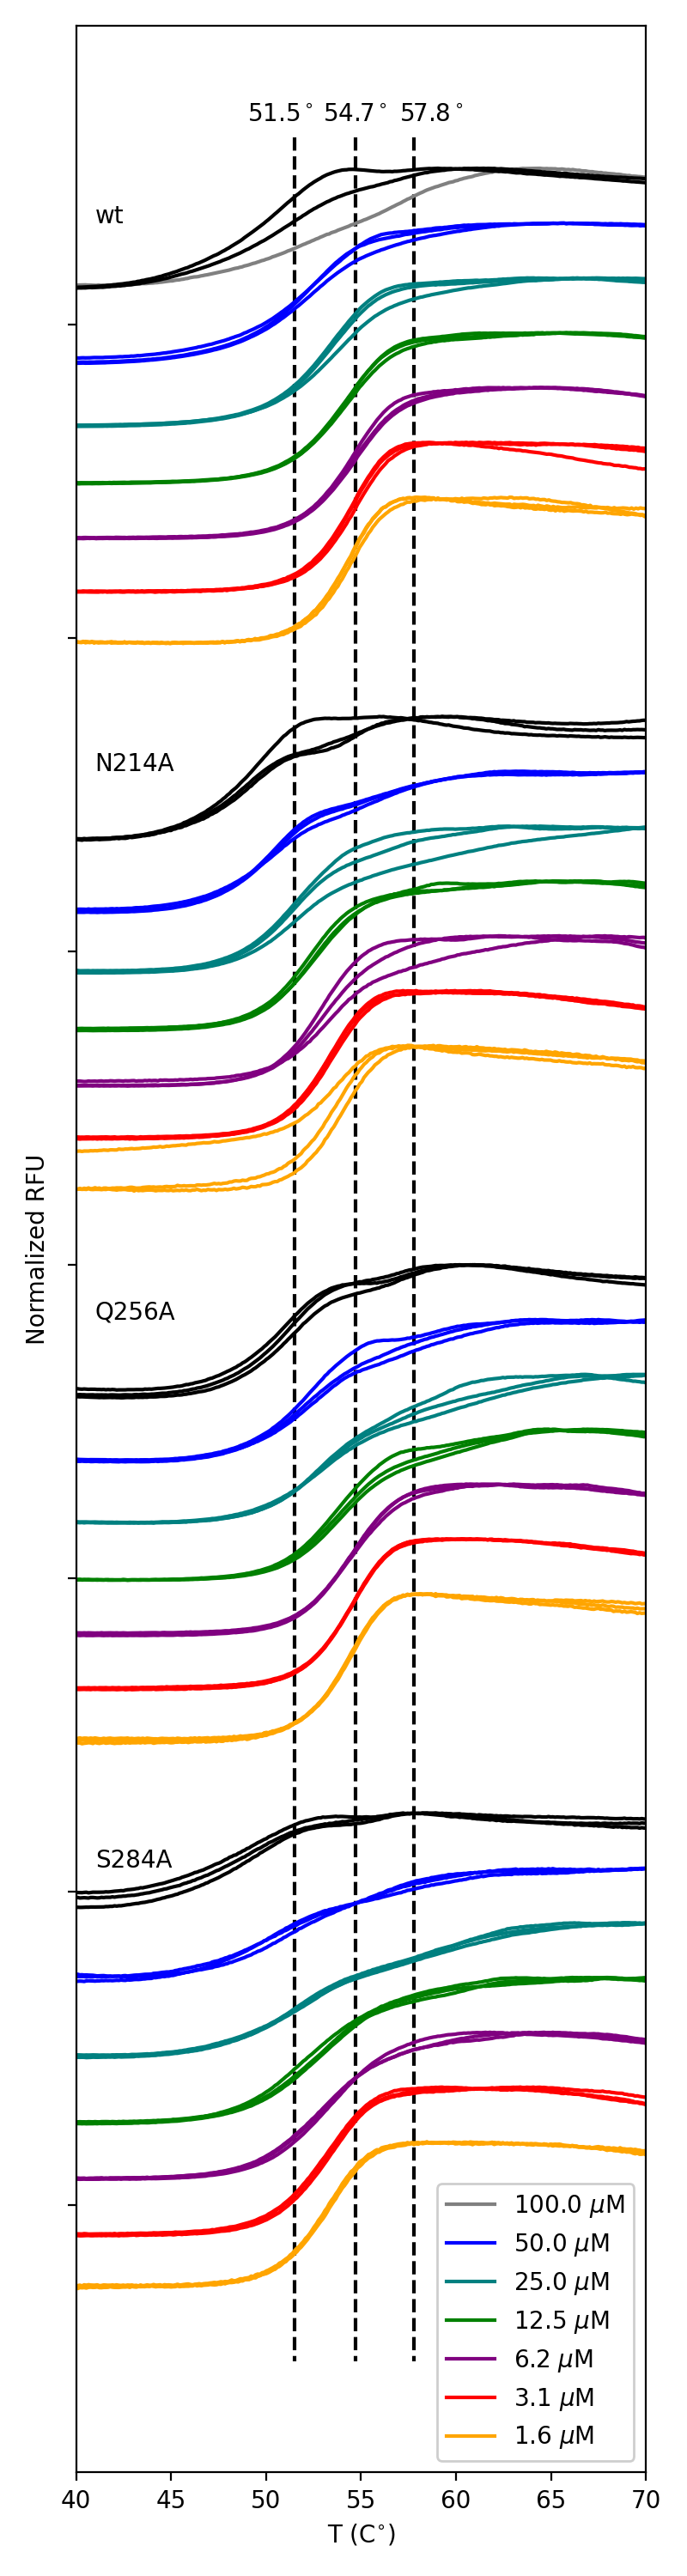

In [7]:
high_T_cutoff = 400
n_repeats     = 3

datasets = ['wt', 'N214A', 'Q256A', 'S284A']
colors = ['k', 'b', 'teal', 'green', 'purple', 'r', 'orange']



minima = np.zeros([ len(datasets), 7, n_repeats ])

plt.figure(figsize=(4,15))
ax = plt.subplot(111)

for idf, df in enumerate([wt, n214a, q256a, s284a]):
    
    T = df.to_numpy()[:high_T_cutoff,0]
    x = df.to_numpy()[:high_T_cutoff,1:]
    n_conc = x.shape[1]//n_repeats
    
    for i in range(n_conc):        
        offset = i  / 10. + idf     # spacing between concentrations
        offset *= 3.5               # spacing between mutants

        if i == 1:
            plt.text(41, -offset + 1, datasets[idf])
        
        for j in range(n_repeats):
            if j == 0 and idf == 0:
                mylabel = '%.1f $\mu$M' % (100.0/(2**i),)
            else:
                mylabel = '_no_legend_'
            
            if i == 0 and j == 0 and idf == 0: # outlier
                color = 'grey'
            else:
                color = colors[i]
            
            ax.plot(T, x[:,i*n_repeats + j] / x[:,i*n_repeats + j].max() - offset, 
                    color=color, label=mylabel)
            
            minima[idf, i, j] = T[ np.argmin(x[:,i*n_repeats + j]) ]


ax.set_yticklabels([])
plt.xlim([40, 70])
#plt.ylim([-660000, 20000])
            
plt.xlabel('T (C$^{\circ}$)')
plt.ylabel('Normalized RFU')

plt.vlines([51.5, 54.7, 57.8], 1.2, -13, 'k', linestyle='dashed')
plt.text(49.0, 1.3, '51.5$^\circ$')
plt.text(53.0, 1.3, '54.7$^\circ$', bbox=dict(facecolor='white', alpha=0.6, ec='white'))
plt.text(57.0, 1.3, '57.8$^\circ$')

plt.legend(loc=4, fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()

## define the model and fit it

Model:

1/2 D <--> M <--> U with eq constants K1, K2

\begin{align*}
K_i &= \exp \left\{ - \frac{\Delta H}{RT} - \frac{\Delta S}{R} \right\} \\
K_1 &= \frac{D}{M^2} \\
K_2 &= \frac{M}{U} \\
s &= s_D D + s_m M + s_U U \\
P &= 2 D + M + U
\end{align*}

In [8]:
R = 8.3145 # J / mol-K

def signal(Ts, Ps, params):
    """
    T = temperatures, in Kelvin
    P = protein concentrations, in uM
    """
    
    sD, sM, sU, dH1, dS1, dH2, dS2 = params
    
    # define the eq constants
    K1 = np.exp( -dH1/(R*Ts) - dS1/R )
    K2 = np.exp( -dH2/(R*Ts) - dS2/R )
    #print(K1, K2)
    
#     K1 = 2.0
    
    # solve for the concentrations of each species: D, M, U
    
    P_array = np.outer(Ps, np.ones(len(Ts)))
    
    # first: U in terms of P...
    a = 2.0 * K1 * np.square(K2)
    b = K1 + 1
    # c = -P
    U = ( -b + np.sqrt( np.square(b) + 4.0 * a * P_array ) ) / (2.0 * a)
    
    # ... then for M and D
    M = K2 * U
    D = K1 * np.square(M)
    
    s_total = sD * D + sM * M + sU * U
    s_total /= (0.5 * D + M + U + 1e-18)
    
    return s_total.T

In [9]:
# declare which dataset {wt, n214a, q256a, s284a}
df = wt

T = df.to_numpy()[:high_T_cutoff,0] + 273.0
x = df.to_numpy()[:high_T_cutoff,1:]
n_conc = x.shape[1] // n_repeats

Ps = np.array([ 100.0/(2**i) for i in range(n_conc) ])
Ps_repeated = np.array([ np.repeat(100.0/(2**i), n_repeats) for i in range(n_conc) ]).flatten()
print(Ps.shape, T.shape, x.shape)

(7,) (400,) (400, 21)


In [16]:
# params_0 = 0.0, 0.1, 1.0, -7e4, 220.0, -7e4, 230.0
params_0 = 0.0, 0.1, 1.0, -7e4, 220.0, -7e4, 230.0

s = signal(T, Ps, params_0)

In [17]:
def diff(params):
    return (x - signal(T, Ps_repeated, params)).flatten()

#                    sD, sM, sU, dH1, dS1, dH2, dS2     
bounds = ( np.array([ 0.0, 0.0, 0.0, -np.inf, -np.inf, -np.inf, -np.inf ]),  # lower
           np.array([ 1.0, 1.0, 1.0,  np.inf,  np.inf,  np.inf,  np.inf ]))  # upper

res = least_squares(diff, params_0)

print(res['x'])

s_opt = signal(T, Ps, res['x'])

[   1285.4219621    18795.72525562  251415.8846162   -69999.20999414
     462.64423914 -245358.51912653     751.8681614 ]


<ipython-input-8-7e9e01930224>:23: RuntimeWarning: overflow encountered in square
  a = 2.0 * K1 * np.square(K2)
<ipython-input-8-7e9e01930224>:26: RuntimeWarning: invalid value encountered in true_divide
  U = ( -b + np.sqrt( np.square(b) + 4.0 * a * P_array ) ) / (2.0 * a)


<IPython.core.display.Javascript object>


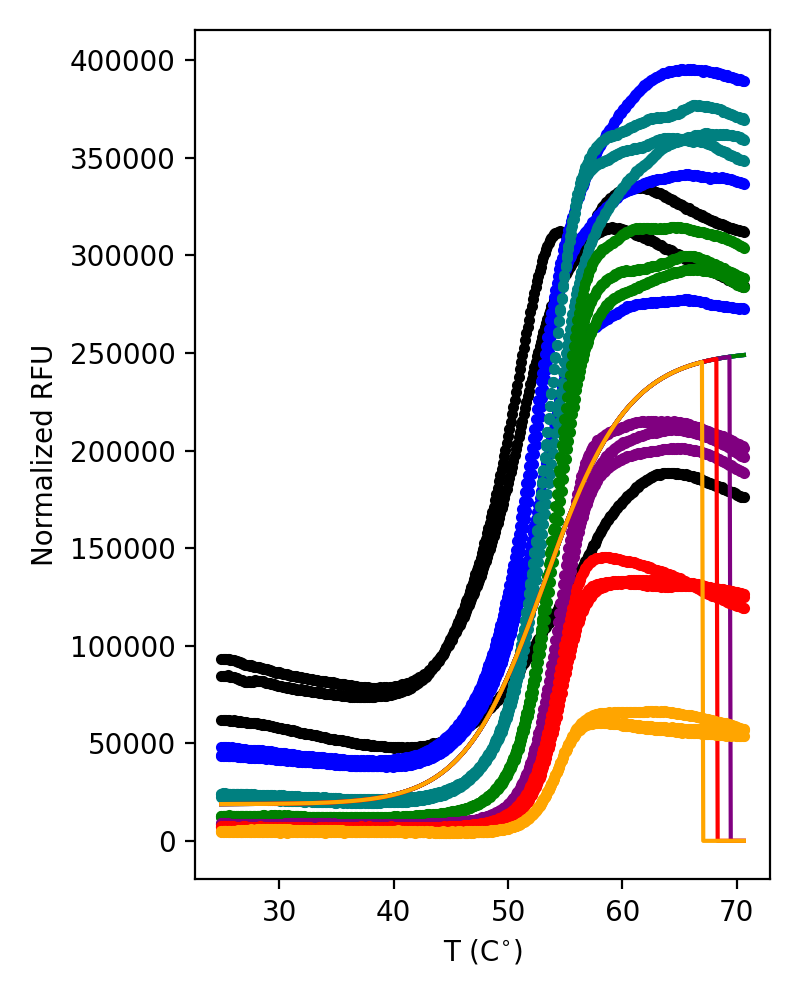

In [18]:
plt.figure(figsize=(4,5))
ax = plt.subplot(111)

for i in range(n_conc):        
    offset = i  / 10.     # spacing between concentrations
    offset *= 3.5               # spacing between mutants
    
    offset = 0.0

    for j in range(n_repeats):
        if j == n_repeats-1:
            mylabel = '%.1f $\mu$M' % (100.0/(2**i),)
        else:
            mylabel = '_no_legend_'

        color = colors[i]

        ax.plot(T - 273.0, x[:,i*n_repeats + j], '.',
                color=color, label=mylabel)

    ax.plot(T - 273.0, s_opt[:,i], color=color, label=mylabel)
        
        
#ax.set_yticklabels([])
#plt.xlim([40, 70])
#plt.ylim([-660000, 20000])
            
plt.xlabel('T (C$^{\circ}$)')
plt.ylabel('Normalized RFU')

# plt.vlines([51.5, 54.7, 57.8], 1.2, -13, 'k', linestyle='dashed')
# plt.text(49.0, 1.3, '51.5$^\circ$')
# plt.text(53.0, 1.3, '54.7$^\circ$', bbox=dict(facecolor='white', alpha=0.6, ec='white'))
# plt.text(57.0, 1.3, '57.8$^\circ$')

#plt.legend(loc=4, fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()